# Copyright

<PRE>
Jelen iPython notebook a Budapesti Műszaki és Gazdaságtudományi Egyetemen tartott
"MI ágensek és multiágensrendszerek fejlesztése" tantárgy segédanyagaként készült.

A notebook bármely részének újra felhasználása, publikálása csak a szerzők írásos beleegyezése esetén megegengedett.

2026 (c) Potyók Csaba (potyok kukac mit pont bme pont hu)
</PRE>

# Teljesítmény és fenntarthatóság

A gyakorlat során megvizsgáljuk különféle nagy nyelvi modell energia szükségletét, valamint a használatukkal okozott ökológiai lábnyomot.

# Szükséges könyvtárak

A gyakorlat során az [Ollama](https://ollama.com) futtató környezetet fogjuk használni, amelyet az Ollama RAG gyakorlat során már kipróbáltunk. A környezeti hatás becslésére pedig a [CodeCarbon](https://pypi.org/project/codecarbon/) Python könyvtárat, amelynek segítségével megbecsélhetjük egy-egy modell hívás energia költségét.

In [1]:
!pip install openai ollama codecarbon pandas matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 83.0 MB/s eta 0:00:00


# Ollama környezet

Annak érdekében, hogy Colab környezetben is használni tudjuk az Ollama futtató környezetet szükséges néhány további függőség telepítése.

1. A `pciutils` csomag szükséges ahhoz, hogy az Ollama felismerje a GPU típusát.
2. A `zstd` csomag szükséges az Ollama telepítőcsomagjának kicsomagolásához.
3. Magát az Ollamát a `curl -fsSL https://ollama.com/install.sh | sh` parancs telepíti a futtatókörnyezetbe.

In [2]:
!sudo apt update
!sudo apt install -y pciutils zstd
!curl -fsSL https://ollama.com/install.sh | sh

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,608 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,864 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main a

## Ollama futtatása

Az Ollama használatához a szolgáltatásnak a háttérben kell futnia a szkriptjeinkkel párhuzamosan. Mivel a notebook kódblokkjai szekvenciálisan futnak, nem tudunk két blokkot egyszerre futtatni. Megoldásként a Python `subprocess` moduljával indítjuk el a szolgáltatást, így az nem blokkolja a további cellák futtatását.

A szolgáltatás az `ollama serve` paranccsal indítható.

A `time.sleep(5)` egy 5 másodperces várakozást iktat be, hogy az Ollama szolgáltatás biztosan elinduljon a modell letöltése előtt.

In [3]:
import threading
import subprocess
import time

def run_ollama_serve():
  log_file = open("ollama_logs.txt", "a")

  subprocess.Popen(
      ["ollama", "serve"],
      stdout=log_file,
      stderr=log_file,
      text=True
  )

thread = threading.Thread(target=run_ollama_serve)
thread.start()
time.sleep(5)

# 1. Mérés

Ebben a szakaszban elvégzünk néhány mérést különféle LLM-eket használva, annak érdekében, hogy meghatározzuk ugyanazt a feladatot milyen energia költségekkel képesek az egyes LLM megvalósítani.

Importáljuk a szükséges könyvtárakat!

In [4]:
from codecarbon import EmissionsTracker
from openai import OpenAI
import pandas as pd

AZ OpenAI kliens segítségével csatlakozzunk a futó Ollama szerverünkhöz!

In [5]:
client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")

Készítsünk egy nagyon egyszerű `qa_test` nevű metódust, amelyben egy LLM hívásban azt kérjük a modellektől, hogy válaszoljanak meg egy kérdést!

In [6]:
def qa_test(client: OpenAI, model_name: str, question: str):
  response = client.responses.create(
      model=model_name,
      input=[
        {
            'role': 'user',
            'content': f'Answer the following question: {question}',
        },
      ])

  return response

## Kiválasztott modellek

A mérés során a következő modelleket fogjuk használni:

| Modell név | Modell paraméter száma |
| :--- | :--- |
| **qwen3.5** | 9.65B |
| **qwen3.5:0.8b** | 873M |
| **llama2:7b** | 6.74B |
| **tinyllama:1.1b** | 638M |

A `Qwen` modellek esetén azt fogjuk megvizsgálni, hogy az LLM gondolkodásának (thinking) engedélyezésével mennyivel nő meg a költség, míg összehasonlításnak két régebbi `LLama` modellt fogunk használni, amelyek szimpla szöveggenerálási feladatra készültek. Külön érdemes megfigyelni, hogy mennyiben változik a modellek képessége és ezzel párhuzamosan az energiaigényük.

### Töltsük le a modelleket

Futtassuk a következő blokkokat, hogy felkerüljenek az Ollama szerverünkre a mérésben használt modellek!

In [7]:
!ollama pull qwen3.5

In [8]:
!ollama pull qwen3.5:0.8b

In [9]:
!ollama pull llama2:7b

In [10]:
!ollama pull tinyllama:1.1b

## Mérőeszköz

Valósítsuk meg a `measure_emissions` metódust, amely megméri egy LLM hívás energiaigényét!

In [11]:
def measure_emissions(client: OpenAI, model_name: str, question: str):
  tracker = EmissionsTracker(project_name=f"{model_name}-qa-test", output_dir=".")
  tracker.start()
  result = qa_test(client, model_name, question)
  tracker.stop()

  print("Generated text:", result.output_text)
  return result, tracker

## Végezzük el a méréseket

Minden modell esetén ismételjük meg ugyanazt a mérést a `measure_emissions` metódus használatával!

In [12]:
measure_emissions(client, "qwen3.5", "What is the capital of Hungary?")

[codecarbon WARNING @ 14:44:19] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 14:44:19] [setup] RAM Tracking...
[codecarbon INFO @ 14:44:19] [setup] CPU Tracking...
[codecarbon WARNING @ 14:44:20] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 14:44:20] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 14:44:20] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 14:44:20] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 14:44:20] [setup] GPU Tracking...
[codecarbon INFO @ 14:44:20] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 14:44:20] The below tracking methods have been set up:
                RAM Tracking Method: RAM p

Generated text: The capital of Hungary is **Budapest**.


(Response(id='resp_561338', created_at=1777819616.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='qwen3.5', object='response', output=[ResponseReasoningItem(id='rs_resp_561338', summary=[Summary(text='Thinking Process:\n\n1.  **Identify the core question:** The user is asking for the capital city of Hungary.\n2.  **Retrieve knowledge:** Access general knowledge about Hungary.\n3.  **Verify the fact:** The capital of Hungary is Budapest.\n4.  **Formulate the answer:** State the answer clearly and concisely.\n5.  **Review for constraints:** No special constraints (like length, tone, etc.) were given, so a direct answer is best.\n\nResult: Budapest.cw', type='summary_text')], type='reasoning', content=None, encrypted_content='Thinking Process:\n\n1.  **Identify the core question:** The user is asking for the capital city of Hungary.\n2.  **Retrieve knowledge:** Access general knowledge about Hungary.\n3.  **Verify the fact:** The capital of Hungary is Budape

In [13]:
measure_emissions(client, "qwen3.5:0.8b", "What is the capital of Hungary?")

[codecarbon WARNING @ 14:46:56] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 14:46:56] [setup] RAM Tracking...
[codecarbon INFO @ 14:46:56] [setup] CPU Tracking...
[codecarbon WARNING @ 14:46:56] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 14:46:56] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 14:46:56] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 14:46:56] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 14:46:56] [setup] GPU Tracking...
[codecarbon INFO @ 14:46:56] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 14:46:56] The below tracking methods have been set up:
                RAM Tracking Method: RAM p

Generated text: The capital of Hungary is **Budapest**.


(Response(id='resp_897511', created_at=1777819659.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='qwen3.5:0.8b', object='response', output=[ResponseReasoningItem(id='rs_resp_897511', summary=[Summary(text='Thinking Process:\n\n1.  **Analyze the Request:** The user is asking for the capital city of Hungary.\n\n2.  **Identify the Subject:** Hungary (a country in Central Europe).\n\n3.  **Retrieve Knowledge:**\n    *   Query: Capital of Hungary.\n    *   Fact: Budapest.\n\n4.  **Verify Facts:**\n    *   Is Budapest the capital? Yes.\n    *   Is Hungary located in Europe? Yes.\n    *   Is it in Eastern Europe? Sometimes debated, but primarily known in Europe.\n\n5.  **Formulate Answer:** State the name of the city clearly.\n\n6.  **Final Check:** Does the answer directly address the prompt? Yes. Is it accurate? Yes.\n\n    *   Draft Answer: The capital of Hungary is Budapest.\n\n7.  **Refinement:** Keep it concise. "The capital of Hungary is Budapest." or "Hu

In [14]:
measure_emissions(client, "llama2:7b", "What is the capital of Hungary?")

[codecarbon WARNING @ 14:47:40] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 14:47:40] [setup] RAM Tracking...
[codecarbon INFO @ 14:47:40] [setup] CPU Tracking...
[codecarbon WARNING @ 14:47:40] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 14:47:40] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 14:47:40] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 14:47:40] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 14:47:40] [setup] GPU Tracking...
[codecarbon INFO @ 14:47:40] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 14:47:40] The below tracking methods have been set up:
                RAM Tracking Method: RAM p

Generated text: 
The capital of Hungary is Budapest.


(Response(id='resp_713294', created_at=1777819707.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='llama2:7b', object='response', output=[ResponseOutputMessage(id='msg_968943', content=[ResponseOutputText(annotations=[], text='\nThe capital of Hungary is Budapest.', type='output_text', logprobs=[])], role='assistant', status='completed', type='message', phase=None)], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[], top_p=1.0, background=False, completed_at=1777819707.0, conversation=None, max_output_tokens=None, max_tool_calls=None, previous_response_id=None, prompt=None, prompt_cache_key=None, prompt_cache_retention=None, reasoning=None, safety_identifier=None, service_tier='default', status='completed', text=ResponseTextConfig(format=ResponseFormatText(type='text'), verbosity=None), top_logprobs=0, truncation='disabled', usage=ResponseUsage(input_tokens=33, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=10

In [15]:
measure_emissions(client, "tinyllama:1.1b", "What is the capital of Hungary?")

[codecarbon WARNING @ 14:48:27] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 14:48:27] [setup] RAM Tracking...
[codecarbon INFO @ 14:48:27] [setup] CPU Tracking...
[codecarbon WARNING @ 14:48:27] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 14:48:27] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 14:48:27] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 14:48:27] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 14:48:27] [setup] GPU Tracking...
[codecarbon INFO @ 14:48:27] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 14:48:27] The below tracking methods have been set up:
                RAM Tracking Method: RAM p

Generated text: The capital of Hungary is Budapest.


(Response(id='resp_825479', created_at=1777819740.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='tinyllama:1.1b', object='response', output=[ResponseOutputMessage(id='msg_263607', content=[ResponseOutputText(annotations=[], text='The capital of Hungary is Budapest.', type='output_text', logprobs=[])], role='assistant', status='completed', type='message', phase=None)], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[], top_p=1.0, background=False, completed_at=1777819740.0, conversation=None, max_output_tokens=None, max_tool_calls=None, previous_response_id=None, prompt=None, prompt_cache_key=None, prompt_cache_retention=None, reasoning=None, safety_identifier=None, service_tier='default', status='completed', text=ResponseTextConfig(format=ResponseFormatText(type='text'), verbosity=None), top_logprobs=0, truncation='disabled', usage=ResponseUsage(input_tokens=47, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens

## Mérés kiértékelése

A `pandas` könyvtár segítségével olvassuk be az elmentett mérési eredményeket, majd vizualizáljuk őket!

In [16]:
df = pd.read_csv("emissions.csv")
summary = df[['project_name', 'emissions', 'energy_consumed', 'duration']]
print(summary)

             project_name  emissions  energy_consumed    duration
0         qwen3.5-qa-test   0.000939         0.003509  155.263809
1    qwen3.5:0.8b-qa-test   0.000272         0.001015   43.421596
2       llama2:7b-qa-test   0.000290         0.001084   47.117261
3  tinyllama:1.1b-qa-test   0.000208         0.000776   33.554922


Mutassuk meg, mekkora a CO2-kibocsátása az egyes LLM-eknek, ugyanazon feladat elvégzése során!

<Axes: title={'center': 'Carbon Emissions per Inference Task'}, xlabel='project_name'>

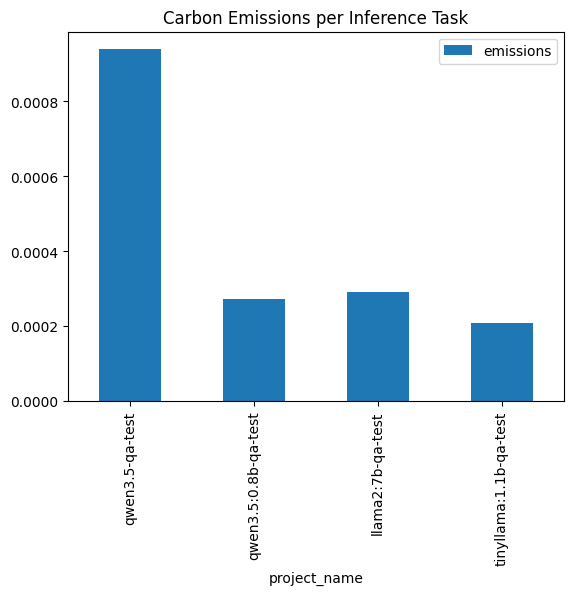

In [17]:
summary.plot(kind="bar", x="project_name", y="emissions", title="Carbon Emissions per Inference Task")

Dobjuk hozzá a mérési eredményekhez a modellek paraméter számát (milliárt paraméterben megadva)!

In [18]:
summary['parameters'] = [9.65, 0.873, 6.74, 0.638]

/tmp/ipykernel_665/1188281432.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary['parameters'] = [9.65, 0.873, 6.74, 0.638]


Vizualizáljuk a paraméter szám függvényében miképp alakul a CO2-kibocsátás!

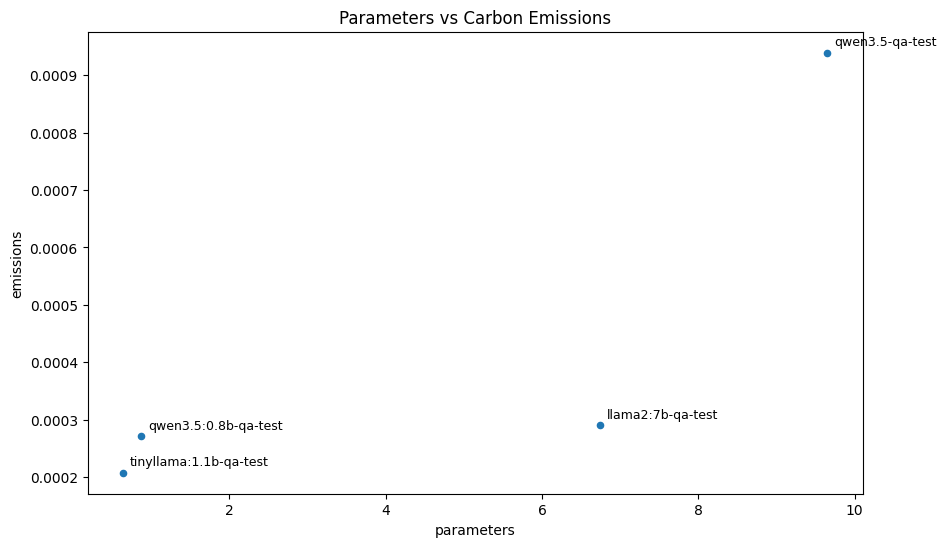

In [19]:
import matplotlib.pyplot as plt

ax = summary.plot(kind="scatter", x="parameters", y="emissions", title="Parameters vs Carbon Emissions", figsize=(10, 6))

for i, row in summary.iterrows():
    ax.annotate(
        row['project_name'],
        (row['parameters'], row['emissions']),
        textcoords="offset points",
        xytext=(5, 5),
        ha='left',
        fontsize=9
    )

plt.show()

# 2. Saját próbálkozások

Találj ki valamilyen feladatot, amely során megvizsgálod a korábban használt LLM-ek energiaigényét!

A feladat célja, hogy különböző problémákon megmérjük a modellek energiaigényét és ebből készítsünk valamilyen egyszerű vizualizációt, valamint egy rövid szöveges értékelést. A feladat megoldásához hasznos lehet például egy néhány kérdésből összeállított benchmark, amelyet lefuttatva az összes modellre nemcsak az energiaigényről, hanem a teljesítőképességekről is kapunk egy képet, amelyet érdemes lehet akár összehasonlítani.

Az értékeléshez töltse fel egyetlen ZIP-állományként a kiegészített Jupyter Notebookot, illetve egy rövid PDF-beszámolót, amely bemutatja a kód működését, illetve a megvalósítás főbb lépéseit.

## Feladat megoldása
A benchmark során három különböző típusú kérdést teszünk fel minden modellnek:
1. **Kódolás:** Egy egyszerű Python függvény megírása.
2. **Logika:** Egy szöveges matematikai feladvány.
3. **Kreativitás:** Rövid történet írása megadott szempontok alapján.

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import time

tasks = {
    'coding': 'Write a Python function to find the nth Fibonacci number using recursion.',
    'logic': 'If five machines take five minutes to make five widgets, how long would it take 100 machines to make 100 widgets?',
    'creative': 'Write a 4-line poem about a robot discovering a flower in a desert.'
}

benchmark_data = []

for model_name in ["qwen3.5", "qwen3.5:0.8b", "llama2:7b", "tinyllama:1.1b"]:
    print(f"Running benchmark for: {model_name}")
    for task_type, question in tasks.items():
        tracker = EmissionsTracker(project_name=f"{model_name}-{task_type}", output_dir=".", save_to_file=False)
        tracker.start()
        start_time = time.time()

        try:
            response = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": question}]
            )
            output_text = response.choices[0].message.content
            duration = time.time() - start_time
            emissions = tracker.stop()

            benchmark_data.append({
                'model': model_name,
                'task': task_type,
                'emissions_g': emissions * 1000 if emissions else 0,
                'duration_sec': duration,
                'response_length': len(output_text)
            })
        except Exception as e:
            print(f"Error with {model_name} on {task_type}: {e}")
            tracker.stop()

bench_df = pd.DataFrame(benchmark_data)
display(bench_df.head())

[codecarbon WARNING @ 15:17:14] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 15:17:14] [setup] RAM Tracking...
[codecarbon INFO @ 15:17:14] [setup] CPU Tracking...
[codecarbon WARNING @ 15:17:14] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 15:17:14] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 15:17:14] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 15:17:14] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 15:17:14] [setup] GPU Tracking...
[codecarbon INFO @ 15:17:14] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 15:17:14] The below tracking methods have been set up:
                RAM Tracking Method: RAM p

Running benchmark for: qwen3.5


[codecarbon INFO @ 15:17:29] Energy consumed for RAM : 0.000042 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:17:29] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 15:17:29] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 15:17:29] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 15:17:29] Energy consumed for all GPUs : 0.000270 kWh. Total GPU Power : 64.8016442956338 W
[codecarbon INFO @ 15:17:29] 0.000489 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 15:17:44] Energy consumed for RAM : 0.000083 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:17:44] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 15:17:44] Energy consumed for All CPU : 0.000354 kWh
[codecarbon INFO @ 15:17:44] Energy consumed for all GPUs : 0.000543 kWh. Total GPU Power : 65.58279612216703 W
[codecarbon INFO @ 15:17:44] 0.000981 kWh of electrici

Running benchmark for: qwen3.5:0.8b


[codecarbon INFO @ 15:22:22] Energy consumed for RAM : 0.000031 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:22:22] Delta energy consumed for CPU with constant : 0.000132 kWh, power : 42.5 W
[codecarbon INFO @ 15:22:22] Energy consumed for All CPU : 0.000132 kWh
[codecarbon INFO @ 15:22:22] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 15:22:22] Energy consumed for all GPUs : 0.000165 kWh. Total GPU Power : 53.316668700939175 W
[codecarbon INFO @ 15:22:22] 0.000328 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 15:22:22] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 15:22:22] [setup] RAM Tracking...
[codecarbon INFO @ 15:22:22] [setup] CPU Tracking...
[codecarbon WARNING @ 15:22:22] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 15:22:22] No CPU tracking mode found. Falling back on estimation based 

Running benchmark for: llama2:7b


[codecarbon INFO @ 15:24:42] Energy consumed for RAM : 0.000025 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:24:42] Delta energy consumed for CPU with constant : 0.000108 kWh, power : 42.5 W
[codecarbon INFO @ 15:24:42] Energy consumed for All CPU : 0.000108 kWh
[codecarbon INFO @ 15:24:42] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 15:24:42] Energy consumed for all GPUs : 0.000152 kWh. Total GPU Power : 59.67179702481539 W
[codecarbon INFO @ 15:24:42] 0.000285 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 15:24:42] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 15:24:42] [setup] RAM Tracking...
[codecarbon INFO @ 15:24:42] [setup] CPU Tracking...
[codecarbon WARNING @ 15:24:42] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 15:24:42] No CPU tracking mode found. Falling back on estimation based o

Running benchmark for: tinyllama:1.1b


[codecarbon INFO @ 15:24:49] Energy consumed for RAM : 0.000010 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:24:49] Delta energy consumed for CPU with constant : 0.000042 kWh, power : 42.5 W
[codecarbon INFO @ 15:24:49] Energy consumed for All CPU : 0.000042 kWh
[codecarbon INFO @ 15:24:49] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 15:24:49] Energy consumed for all GPUs : 0.000057 kWh. Total GPU Power : 57.70302059531787 W
[codecarbon INFO @ 15:24:49] 0.000109 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 15:24:49] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 15:24:49] [setup] RAM Tracking...
[codecarbon INFO @ 15:24:49] [setup] CPU Tracking...
[codecarbon WARNING @ 15:24:49] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 15:24:49] No CPU tracking mode found. Falling back on estimation based o

,model,task,emissions_g,duration_sec,response_length
0,qwen3.5,coding,0.295962,33.820808,1666
1,qwen3.5,logic,0.424933,48.159085,388
2,qwen3.5,creative,1.890513,214.412164,133
3,qwen3.5:0.8b,coding,0.087813,11.152344,1182
4,qwen3.5:0.8b,logic,0.667830,76.067793,1213


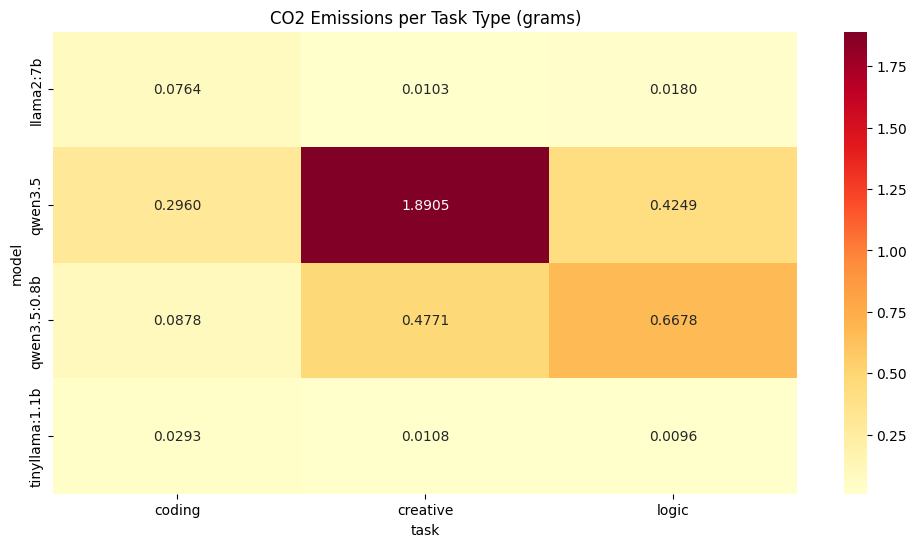

In [28]:
if not bench_df.empty:
    plt.figure(figsize=(12, 6))
    pivot_df = bench_df.pivot(index='model', columns='task', values='emissions_g')
    sns.heatmap(pivot_df, annot=True, cmap='YlOrRd', fmt='.4f')
    plt.title('CO2 Emissions per Task Type (grams)')
    plt.show()
else:
    print('Nincs adat a vizualizációhoz. Ellenőrizd a mérések futását!')

Az idő és a kibocsátás kapcsolata, valamint a modellek 'energia-hatékonysága' (CO2/karakter).

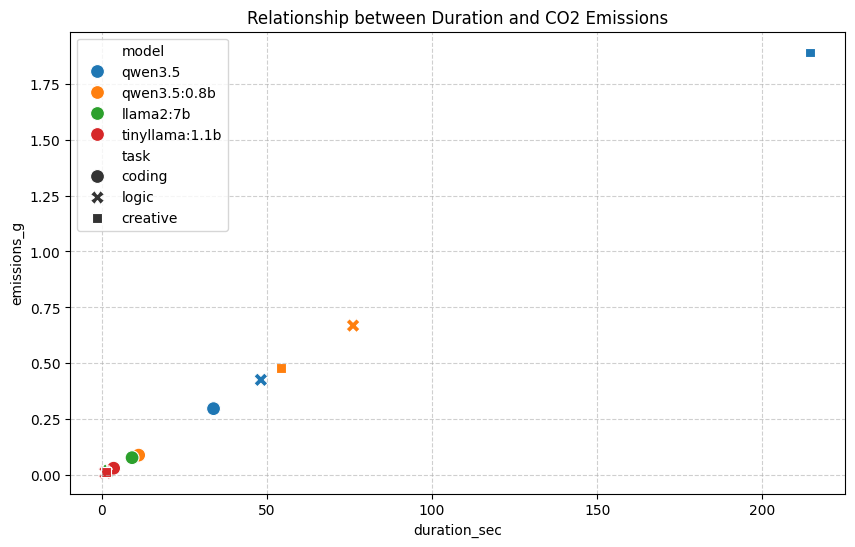

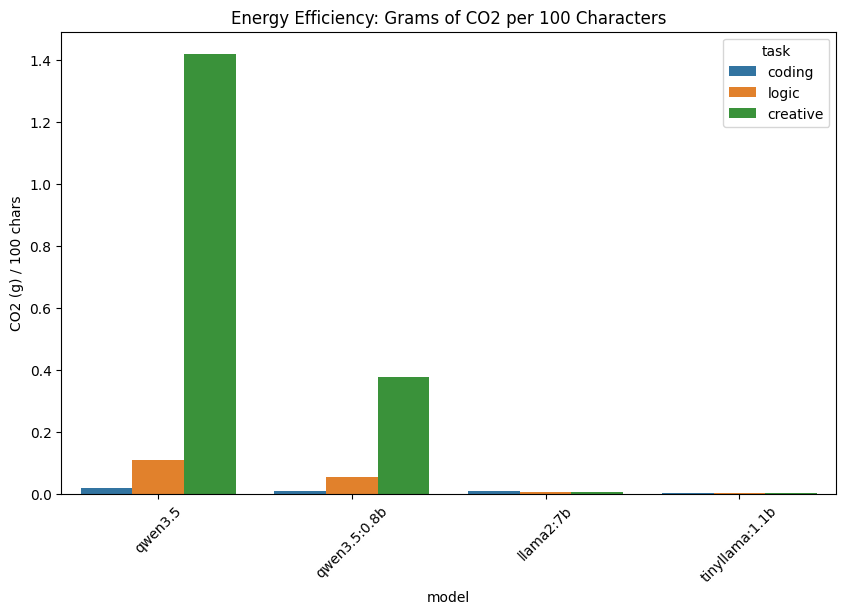

In [29]:
# 1. Pontdiagram: Időtartam vs. Kibocsátás
plt.figure(figsize=(10, 6))
sns.scatterplot(data=bench_df, x='duration_sec', y='emissions_g', hue='model', style='task', s=100)
plt.title('Relationship between Duration and CO2 Emissions')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Hatékonyság számítása: Gramm CO2 / 100 karakter
bench_df['emissions_per_100char'] = (bench_df['emissions_g'] / bench_df['response_length']) * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=bench_df, x='model', y='emissions_per_100char', hue='task')
plt.title('Energy Efficiency: Grams of CO2 per 100 Characters')
plt.ylabel('CO2 (g) / 100 chars')
plt.xticks(rotation=45)
plt.show()

A modellek stabilitása és a generálási sebességüket összehasonlítása az energiafelhasználással

/tmp/ipykernel_665/23461906.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bench_df, x='model', y='emissions_g', palette='Set3')


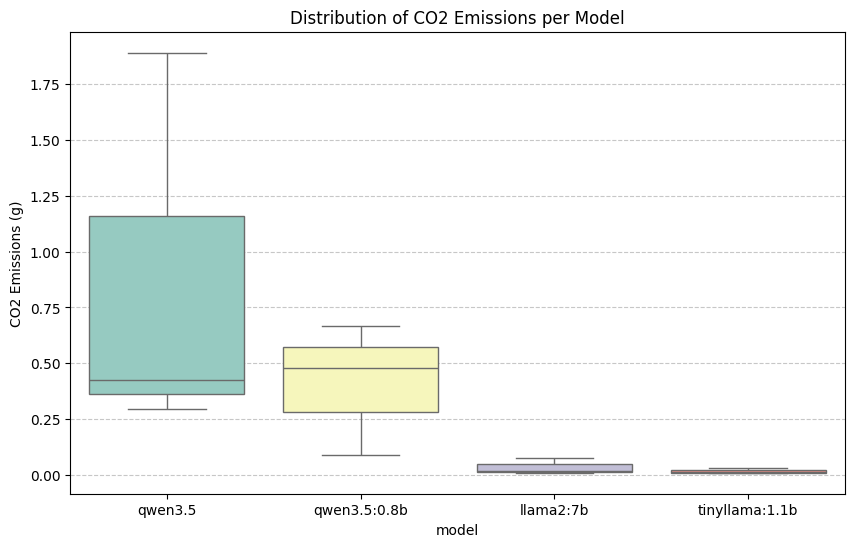

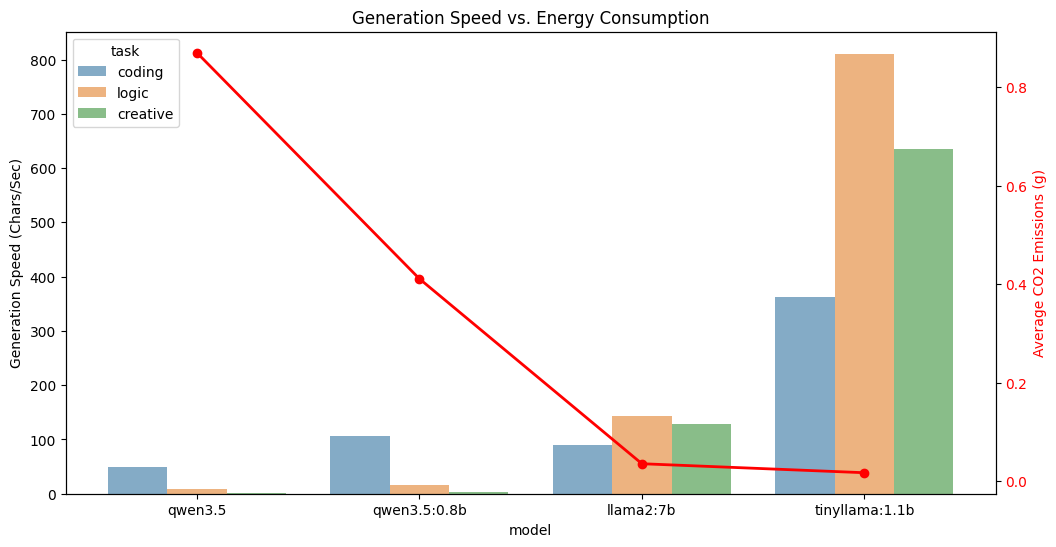

In [30]:
# 1. Dobozdiagram: Kibocsátás eloszlása modellenként
plt.figure(figsize=(10, 6))
sns.boxplot(data=bench_df, x='model', y='emissions_g', palette='Set3')
plt.title('Distribution of CO2 Emissions per Model')
plt.ylabel('CO2 Emissions (g)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Sebesség számítása: Karakter / másodperc
bench_df['chars_per_sec'] = bench_df['response_length'] / bench_df['duration_sec']

fig, ax1 = plt.subplots(figsize=(12, 6))

# Sebesség oszlopdiagram
sns.barplot(data=bench_df, x='model', y='chars_per_sec', hue='task', ax=ax1, alpha=0.6)
ax1.set_ylabel('Generation Speed (Chars/Sec)')
ax1.set_title('Generation Speed vs. Energy Consumption')

# Energiaigény vonaldiagram a második tengelyen
ax2 = ax1.twinx()
# Átlagoljuk a modellek fogyasztását a vonalhoz
model_avg_emissions = bench_df.groupby('model')['emissions_g'].mean().reindex(bench_df['model'].unique())
ax2.plot(range(len(model_avg_emissions)), model_avg_emissions, color='red', marker='o', linewidth=2, label='Avg Emissions (g)')
ax2.set_ylabel('Average CO2 Emissions (g)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.show()